#### Forward kinematics of `Panda` bookshelf environment

In [1]:
%run ../../package/init_scripts/init_dev_env.py
from package.panda_env import * 

Initializing development environment with [9] scripts

[0/9] Calling [init_ipython_setup.py]
Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.

[1/9] Calling [init_utility.py]
[utility] package initialized.
 from utils import *
 from viz import *
 from filters import *

[2/9] Calling [init_kinematics.py]
[kinematics] package initialized.
 from transforms import *
 from numpy_chain import *

[3/9] Calling [init_mujoco_sim.py]
[mujoco_sim] package initialized.
 mujoco version: (3, 4, 0)
 from parser import *
 from mujoco_utils import *
 from mujoco_draw import *
 from mujoco_ik import *

[4/9] Calling [init_qt.py]
[qt] package initialized.

[5/9] Calling [init_gaussian_process.py]
[gaussian_process] package initialized.
 from kernels import *
 from gp_utils import *

[6/9] Calling [init_mocap.py]
[m

In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files=[
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/bookshelf/bookshelf_base.xml',
        './asset/bookshelf/bookshelf_deep.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [5] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/bookshelf/bookshelf_base.xml]
  - [3] [./asset/bookshelf/bookshelf_deep.xml]
  - [4] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[29]
 [0/29] [world] parent:[world] mass:[0.00]kg
 [1/29] [panda_base] parent:[world] mass:[0.00]kg
 [2/29] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/29] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/29] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/29] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/29] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/29] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/29] [panda_link_

active joint names: ['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_joint6', 'panda_joint7', 'left_thumb_1_joint', 'left_thumb_2_joint', 'left_index_1_joint', 'left_middle_1_joint', 'left_ring_1_joint', 'left_little_1_joint']
length comparison - qactive: 13, active_joint_names: 13
active joint names: ['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_joint6', 'panda_joint7', 'left_thumb_1_joint', 'left_thumb_2_joint', 'left_index_1_joint', 'left_middle_1_joint', 'left_ring_1_joint', 'left_little_1_joint']
length comparison - qactive: 13, active_joint_names: 13
active joint names: ['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_joint6', 'panda_joint7', 'left_thumb_1_joint', 'left_thumb_2_joint', 'left_index_1_joint', 'left_middle_1_joint', 'left_ring_1_joint', 'left_little_1_joint']
length comparison - qactive: 13, active_joint_names: 13
active joint names: ['panda_joint1

2026-03-12 21:53:50.943 python[12284:2218995] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


active joint names: ['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_joint6', 'panda_joint7', 'left_thumb_1_joint', 'left_thumb_2_joint', 'left_index_1_joint', 'left_middle_1_joint', 'left_ring_1_joint', 'left_little_1_joint']
length comparison - qactive: 13, active_joint_names: 13
Final RGB image captured.


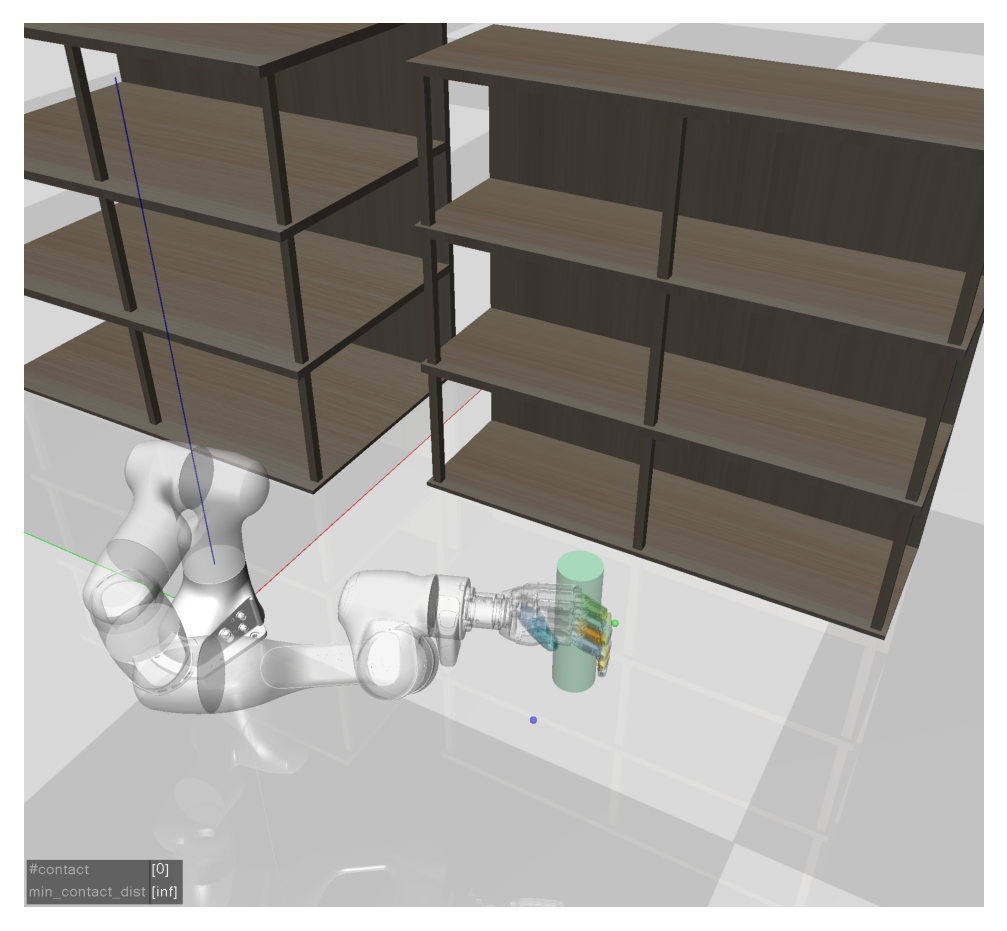

Done.


In [3]:
# Configuration
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
q_inspire0            = get_q_inspire(env)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
q_pandas              = get_q_pandas_bookshelf()

# Initialize env
set_panda_bookshelf_env(env,panda_joints,inspire_joints,q_pandas['right_2f'],q_inspire0)

# Sliders
sliders = MultiSliderQtWidget(
    window_width  = 0.2,
    window_height = 0.4,
    label_texts   = env.active_joint_names,
    label_colors  = get_label_colors_from_joint_axis(env,env.active_joint_names),
    slider_vals   = env.get_qpos(joint_names=env.active_joint_names),
    slider_mins   = env.active_joint_mins,
    slider_maxs   = env.active_joint_maxs,
)

# Initialize buttons
buttons = MultiRadioQtWidget(
    title         = "Set Panda joint position",
    label_texts   = ["Panda pose"],
    option_texts  = [["q_right_2f","q_right_3f","q_left_2f","q_left_3f"]],
    initial_texts = ["q_right_2f"],
    y_offset      = 0.45,
    window_width  = 0.2,
    window_height = 0.05,
)

# Loop
while env.is_viewer_alive():
    # Update
    qactive = sliders.get_values()
    print(f"active joint names: {env.active_joint_names}")
    print(f"length comparison - qactive: {len(qactive)}, active_joint_names: {len(env.active_joint_names)}")
    qrev = env.get_qrev_from_qactive(qactive)
    env.forward(q=qrev,joint_names=env.rev_joint_names)
    T_palm = get_T_palm_panda_inspire(env)
    T_cylinder = view_in_world(T=p2t(p_cylinder_offset0),T_wl=T_palm)
    env.set_T('body_cylinder','base_body',T_cylinder)

    # Set Panda joint position
    if buttons.is_toggled(label_text="Panda pose"):
        panda_pose = buttons.get_option("Panda pose")
        if panda_pose == "q_right_2f": env.forward(q=q_pandas['right_2f'],joint_names=panda_joints)
        if panda_pose == "q_right_3f": env.forward(q=q_pandas['right_3f'],joint_names=panda_joints)
        if panda_pose == "q_left_2f": env.forward(q=q_pandas['left_2f'],joint_names=panda_joints)
        if panda_pose == "q_left_3f": env.forward(q=q_pandas['left_3f'],joint_names=panda_joints)
        T_palm = get_T_palm_panda_inspire(env)
        sliders.set_values(values=env.get_qpos(env.active_joint_names))

    # Get contact information
    contact_info = env.get_contact_info()
    
    # Render
    env.viewer_text_overlay('#contact','[%d]'%(contact_info['n_contact']))
    env.viewer_text_overlay('min_contact_dist','[%.3f]'%(contact_info['min_contact_dist']))
    env.plot_global_coordinate_axes()
    env.plot_contact_info()
    env.render()

# Final image show
imshow(env.final_rgb_img)

# Close
sliders.close()
buttons.close()
print("Done.")